# Figuras do artigo (essencial)

Rode ablações antes. Edite `CFG` / `COHORT`. Backup: `6_results.ipynb.bak_full`.

**Dois papéis (não misturar):**

| Papel | O quê | Secção |
|-------|--------|--------|
| **A. Âncora** | `t1_only` em `COHORT` · shape (teto) · svm — heatmap, ROC, estabilidade; CN×AD em Q4 vol | §§1–2 |
| **B. Claim longitudinal** | Q4 `t1_d21_d32` vs T1 nas 4 coortes; late 3 specs | §3 |

| # | Figura / tabela | Papel |
|---|-----------------|-------|
| 1 | T1 vs Q4 (shape/vol) + late + leaky na claim | A |
| 2 | Heatmap + ROC `smci_pmci` (+ sanity `cn_ad`) + estabilidade | A |
| 3 | Encoding multi-cohort: Δ(Q4−T1) × `t_imagens` | **B** |

`cn_ad` → `ablation_results_d21d32/vol_cn_ad/`. Late → `ablation_results_late_fusion/`. Sem `abs` / early.


In [1]:
import json
import sys
from dataclasses import dataclass
from pathlib import Path

_MOD = Path.cwd() / "modules"
if str(_MOD) not in sys.path:
    sys.path.insert(0, str(_MOD))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import roc_auc_score, roc_curve

from ablation_analysis import (
    TIME_ORDER,
    anatomical_key,
    feature_freq_table_grouped,
    filter_ablation_config,
    filter_temporally_stable,
    parse_feature,
    pooled_auc,
    pooled_predictions,
    patient_mean_auc,
    patient_mean_predictions,
    prepare_ablation_df,
    short_anatomical_key,
    summary_with_pooled,
)
# ── editar aqui ──────────────────────────────────────────────
COHORT = "48m_12m"
BASE = Path("csvs/cohorts") / COHORT
SAVE_FIGS = True
ARTIGO_DIR = Path("artigo")
FIG_DIR = ARTIGO_DIR / "figures"
TABLE_DIR = ARTIGO_DIR / "tables"
SUMMARY_PATH = BASE / "all_protocols_summary.csv"

COHORTS_DIR = Path("csvs/cohorts")
COMPARE_DIR = Path("csvs/cohort_comparison")
COHORTS_COMPARE = [
    c for c in (
        "36m_6m", "36m_12m",
        "48m_6m", "48m_12m",
    )
    if (COHORTS_DIR / c / "ablation_results_t1_only").is_dir()
]

RESULTS_MAIN_PROTOCOLS = ("t1_only", "t1_d21_d32")
RESULTS_SUPP_PROTOCOLS = (
    "t1_only", "t1_d21_d32", "t1_d21_d32_global",
    "clinica", "clinica+img_t1",
)
RESULTS_TOP_N = 3
RESULTS_TOP_GROUP = ("task", "protocol", "with_combat")

MOD_ORDER = ["vol", "shape", "texture", "disp", "firstorder"]
MODEL_ORDER = ["svm", "rf", "elasticnet"]
ROC_COLORS = {"svm": "#4477AA", "rf": "#EE6677", "elasticnet": "#228833"}
N_BOOT_AUC = 2000
STAB_MIN_PCT = 70
STAB_MIN_TIMEPOINTS = 0

MOD_LABELS = {
    "vol": "Volume", "shape": "Shape", "texture": "Texture",
    "disp": "DVF", "firstorder": "First-order",
}
MODEL_LABELS = {"svm": "SVM", "rf": "RF", "elasticnet": "Elastic-Net"}

PROTOCOL_ROOTS = {
    "t1_only": BASE / "ablation_results_t1_only",
    "t1_d21_d32": BASE / "ablation_results_d21d32",
    "t1_d21_d32_global": BASE / "ablation_results_leaky_d21d32",
    "clinica": BASE / "ablation_results_clinic",
    "clinica+img_t1": BASE / "ablation_results_clinic_img_t1_only",
}
LATE_FUSION_RESULTS_ROOT = BASE / "ablation_results_late_fusion"


@dataclass(frozen=True)
class CFG:
    selection_mode: str = "l1_stable"
    with_combat: bool = False
    task_primary: str = "smci_pmci"
    task_sanity: str = "cn_ad"
    model_primary: str = "svm"
    modality_primary: str = "shape"
    model_sanity: str = "svm"
    modality_sanity: str = "vol"


CFG = CFG()
TASK_LABELS = {"cn_ad": "CN × AD", "smci_pmci": "sMCI × pMCI"}
CM_LABELS = {
    "cn_ad": ("CN", "AD"),
    "smci_pmci": ("sMCI", "pMCI"),
}


def _csv(mod_dir: Path, stem: str, sel: str) -> Path:
    for name in (f"{stem}_{sel}.csv", f"{stem}.csv"):
        p = mod_dir / name
        if p.is_file():
            return p
    raise FileNotFoundError(f"{stem} ausente em {mod_dir}")


def _iter_mod_dirs(root: Path, protocol: str):
    for mod in MOD_ORDER:
        d = root / mod
        if d.is_dir():
            yield d
    # sanity CN×AD só no encoding Q4
    if protocol == "t1_d21_d32":
        cn = root / "vol_cn_ad"
        if cn.is_dir():
            yield cn


def load_summary(protocol: str, sel: str = CFG.selection_mode) -> pd.DataFrame:
    root = PROTOCOL_ROOTS[protocol]
    frames = []
    for d in _iter_mod_dirs(root, protocol):
        try:
            frames.append(pd.read_csv(_csv(d, "ablation_summary", sel)))
        except FileNotFoundError:
            pass
    if not frames:
        raise FileNotFoundError(f"sem summary em {root}")
    return pd.concat(frames, ignore_index=True)


def load_ablation(protocol: str, sel: str = CFG.selection_mode) -> pd.DataFrame:
    root = PROTOCOL_ROOTS[protocol]
    frames = []
    for d in _iter_mod_dirs(root, protocol):
        try:
            frames.append(pd.read_csv(_csv(d, "ablation_results_all", sel)))
        except FileNotFoundError:
            pass
    if not frames:
        raise FileNotFoundError(f"sem ablation_results_all em {root}")
    return prepare_ablation_df(pd.concat(frames, ignore_index=True))


def save_fig(fig, name: str) -> None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    path = FIG_DIR / f"{name}.pdf"
    if SAVE_FIGS:
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Salvo:", path)
    plt.show()
    plt.close(fig)


ablation_t1 = load_ablation("t1_only")
ablation_q4 = load_ablation("t1_d21_d32")
summary_t1 = summary_with_pooled(ablation_t1)
summary_q4 = summary_with_pooled(ablation_q4)
summary_all = pd.read_csv(SUMMARY_PATH) if SUMMARY_PATH.is_file() else pd.DataFrame()
print(f"cohort={COHORT} | selection={CFG.selection_mode} | combat={CFG.with_combat}")
print(f"ablation_t1: {len(ablation_t1)} linhas | mods={sorted(ablation_t1['modality'].astype(str).unique())}")
print(f"ablation_q4: {len(ablation_q4)} linhas | mods={sorted(ablation_q4['modality'].astype(str).unique())}")
_cn = ablation_q4.loc[ablation_q4["task"].astype(str) == "cn_ad"]
if _cn.empty:
    print("cn_ad: sem dados em vol_cn_ad")
else:
    print(
        "cn_ad mods × models:",
        sorted(_cn.groupby(["modality", "model_key"]).size().index.tolist()),
    )


cohort=48m_12m | selection=l1_stable | combat=False
ablation_t1: 750 linhas | mods=['disp', 'firstorder', 'shape', 'texture', 'vol']
ablation_q4: 1500 linhas | mods=['disp', 'firstorder', 'shape', 'texture', 'vol']
cn_ad mods × models: [('disp', 'elasticnet'), ('disp', 'rf'), ('disp', 'svm'), ('firstorder', 'elasticnet'), ('firstorder', 'rf'), ('firstorder', 'svm'), ('shape', 'elasticnet'), ('shape', 'rf'), ('shape', 'svm'), ('texture', 'elasticnet'), ('texture', 'rf'), ('texture', 'svm'), ('vol', 'elasticnet'), ('vol', 'rf'), ('vol', 'svm')]


## Consolidação (1 cohort)

Gera/atualiza `all_protocols_summary.csv` (T1, Q4, late, leaky).


In [2]:
CONFIG_COLS = ["task", "modality", "model_key", "with_combat", "selection_mode"]
CONSOLIDATION_PROTOCOL_ROOTS = {
    "t1_only": BASE / "ablation_results_t1_only",
    "t1_d21_d32": BASE / "ablation_results_d21d32",
    "late_scan": BASE / "ablation_results_late_fusion",
    "t1_d21_d32_global": BASE / "ablation_results_leaky_d21d32",
    "clinica": BASE / "ablation_results_clinic",
    "clinica+img_t1": BASE / "ablation_results_clinic_img_t1_only",
}


def _summary_files(root: Path) -> list[Path]:
    def _ok(p: Path) -> bool:
        blob = f"{p.parent.name}/{p.stem}".lower()
        return "backup" not in blob and "_cn_ad" not in blob

    files = [f for f in root.glob("*/ablation_summary.csv") if _ok(f)]
    files += [
        f for f in root.glob("*summary*.csv")
        if not f.name.startswith("all_") and _ok(f)
    ]
    return files


def build_all_protocols_summary() -> pd.DataFrame:
    frames = []
    for proto, root in CONSOLIDATION_PROTOCOL_ROOTS.items():
        if not root.is_dir():
            continue
        for f in _summary_files(root):
            df = pd.read_csv(f)
            if root.name == "ablation_results_late_fusion":
                row_proto = f"late__{f.parent.name}"
            else:
                row_proto = proto
            df.insert(0, "protocol", row_proto)
            df["source_file"] = str(f.relative_to(BASE))
            df["source_mtime"] = pd.Timestamp(f.stat().st_mtime, unit="s")
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    master = pd.concat(frames, ignore_index=True)
    keys = ["protocol"] + [c for c in CONFIG_COLS if c in master.columns]
    master = master.sort_values("source_mtime").drop_duplicates(keys, keep="last")
    front = ["protocol", *CONFIG_COLS, "auc_patient_mean", "auc_pooled", "auc_mean", "auc_std", "n_features_mean"]
    front = [c for c in front if c in master.columns]
    master = master[front + [c for c in master.columns if c not in front]]
    rank_col = "auc_patient_mean" if "auc_patient_mean" in master.columns else "auc_pooled"
    return master.sort_values([rank_col, "protocol"], ascending=[False, True]).reset_index(drop=True)


summary_all = build_all_protocols_summary()
if summary_all.empty:
    print(f"{SUMMARY_PATH.name} vazio — rode ablations antes")
else:
    summary_all.to_csv(SUMMARY_PATH, index=False)
    print(f"Salvo: {SUMMARY_PATH} | {len(summary_all)} linhas")
    print(summary_all.groupby("protocol").size().rename("linhas").to_string())
    show_cols = ["protocol"] + [c for c in CONFIG_COLS if c in summary_all.columns]
    show_cols += [c for c in (
        "auc_patient_mean", "auc_pooled", "auc_mean", "auc_std", "n_features_mean"
    ) if c in summary_all.columns]
    display(summary_all[show_cols].head(20))


Salvo: csvs/cohorts/48m_12m/all_protocols_summary.csv | 69 linhas
protocol
clinica                                                                                           1
clinica+img_t1                                                                                    1
late__t1_d21d32_shape__t1_d21d32_texture__t1_d21d32_disp__t1_d21d32_firstorder                    1
late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d32_disp__t1_d21d32_firstorder                        1
late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d32_texture__t1_d21d32_disp                           1
late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d32_texture__t1_d21d32_disp__t1_d21d32_firstorder     1
late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d32_texture__t1_d21d32_firstorder                     1
late__t1_d21d32_vol__t1_d21d32_texture__t1_d21d32_disp__t1_d21d32_firstorder                      1
late__t1_shape__t1_d21d32_disp                                                                    1
late__t1_shape__t1_d21d32

,protocol,task,modality,model_key,with_combat,selection_mode,auc_patient_mean,auc_pooled,auc_mean,auc_std,n_features_mean
0,t1_d21_d32,cn_ad,shape,rf,False,l1_stable,0.912615,0.898798,0.902249,0.057410,5.94
1,t1_d21_d32,cn_ad,shape,svm,False,l1_stable,0.909561,0.895874,0.900556,0.046912,5.94
2,t1_d21_d32,cn_ad,shape,elasticnet,False,l1_stable,0.907681,0.891849,0.905541,0.045990,5.84
3,t1_d21_d32,cn_ad,vol,rf,False,l1_stable,0.881137,0.869651,0.875296,0.051853,11.46
4,t1_d21_d32,cn_ad,vol,elasticnet,False,l1_stable,0.875969,0.859576,0.864933,0.056499,11.28
5,t1_d21_d32,cn_ad,vol,svm,False,l1_stable,0.873033,0.853882,0.850110,0.104348,11.46
6,clinica+img_t1,smci_pmci,shape,svm,False,l1_stable,0.845775,0.829413,0.821336,0.119185,6.42
7,t1_d21_d32,cn_ad,firstorder,svm,False,l1_stable,0.840146,0.802939,0.811053,0.073848,8.36
8,t1_d21_d32,cn_ad,firstorder,rf,False,l1_stable,0.821588,0.796069,0.802262,0.070815,8.36
9,clinica,smci_pmci,clinical,svm,False,none,0.811921,0.801353,0.808384,0.083970,5.00


## 1. Protocolos no primary (âncora A)

Shape T1 (teto) vs Shape/Vol Q4, late 3 specs, leaky vol. SVM · `COHORT`.
Stats FDR: `7_stats`.


Âncora A | Protocolos | 48m_12m | smci_pmci | svm | no ComBat


,label,protocol,modality,auc_patient_mean,auc_std,auc_pooled,n_features_mean
0,Shape T1,t1_only,shape,0.7593,0.0732,0.7493,1.42
1,Shape Q4,t1_d21_d32,shape,0.7610,0.0945,0.7426,4.84
2,Vol T1,t1_only,vol,0.6409,0.1004,0.6282,1.72
3,Vol Q4,t1_d21_d32,vol,0.7295,0.0871,0.7132,5.58
4,Late T1,late__t1_vol__t1_shape__t1_texture__t1_disp__t...,late__t1_vol__t1_shape__t1_texture__t1_disp__t...,0.7405,0.0794,0.7234,26.68
5,Late Q4,late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d3...,late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d3...,0.7648,0.0800,0.7427,55.58
6,Late ancora,late__t1_shape__t1_d21d32_vol__t1_d21d32_textu...,late__t1_shape__t1_d21d32_vol__t1_d21d32_textu...,0.7668,0.0852,0.7430,52.16
7,Leaky Q4 vol,t1_d21_d32_global,vol,0.7344,0.0807,0.7206,6.00


CSV: csvs/cohorts/48m_12m/protocol_compare_primary.csv
Salvo: artigo/figures/protocol_compare_primary.pdf


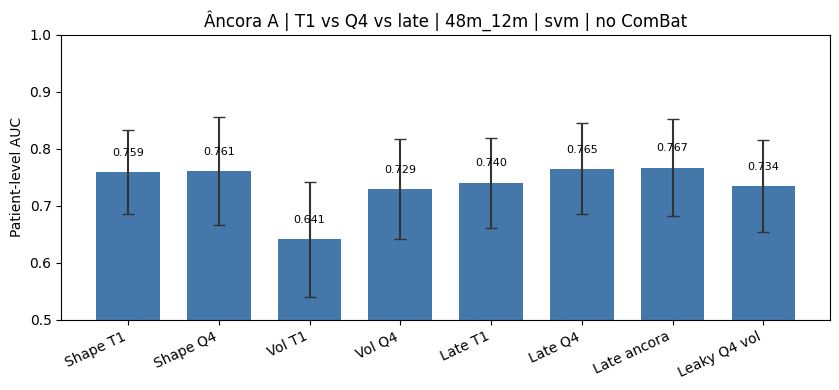

In [3]:
# Âncora A — T1 vs Q4 vs late vs leaky (COHORT / CFG)
LATE_ALL_T1 = "late__t1_vol__t1_shape__t1_texture__t1_disp__t1_firstorder"
LATE_ALL_Q4 = (
    "late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d32_texture"
    "__t1_d21d32_disp__t1_d21d32_firstorder"
)
LATE_ANCORA = (
    "late__t1_shape__t1_d21d32_vol__t1_d21d32_texture"
    "__t1_d21d32_disp__t1_d21d32_firstorder"
)
PROTOCOL_COMPARE = (
    ("t1_only", "shape", "Shape T1"),
    ("t1_d21_d32", "shape", "Shape Q4"),
    ("t1_only", "vol", "Vol T1"),
    ("t1_d21_d32", "vol", "Vol Q4"),
    (LATE_ALL_T1, LATE_ALL_T1, "Late T1"),
    (LATE_ALL_Q4, LATE_ALL_Q4, "Late Q4"),
    (LATE_ANCORA, LATE_ANCORA, "Late ancora"),
    ("t1_d21_d32_global", "vol", "Leaky Q4 vol"),
)
BACKUP_RE = r"backup|_cn_ad"

rows = []
if summary_all.empty:
    print("summary_all vazio — rode consolidação antes")
else:
    s = summary_all.copy()
    if "with_combat" in s.columns:
        s["with_combat"] = s["with_combat"].map(
            lambda x: str(x).strip().lower() in ("1", "true", "yes")
        )
    if "source_file" in s.columns:
        s = s.loc[
            ~s["source_file"].astype(str).str.contains(BACKUP_RE, regex=True, na=False)
        ]

    for proto, mod, label in PROTOCOL_COMPARE:
        hit = s.query(
            "protocol == @proto and task == @CFG.task_primary "
            "and modality == @mod and model_key == @CFG.model_primary "
            "and with_combat == False"
        )
        if hit.empty:
            print(f"MISS: {label} ({proto}/{mod})")
            continue
        r = hit.iloc[0]
        rows.append({
            "label": label,
            "protocol": proto,
            "modality": mod,
            "auc_patient_mean": float(r["auc_patient_mean"]),
            "auc_std": float(r["auc_std"]) if pd.notna(r.get("auc_std")) else float("nan"),
            "auc_pooled": float(r["auc_pooled"]) if "auc_pooled" in r and pd.notna(r["auc_pooled"]) else float("nan"),
            "n_features_mean": r.get("n_features_mean"),
            "source_file": r.get("source_file", ""),
        })

    proto_cmp = pd.DataFrame(rows)
    if proto_cmp.empty:
        print("Nenhuma linha protocol compare — falta T1/Q4/late?")
    else:
        order = [lab for _, _, lab in PROTOCOL_COMPARE if lab in set(proto_cmp["label"])]
        proto_cmp["label"] = pd.Categorical(proto_cmp["label"], categories=order, ordered=True)
        proto_cmp = proto_cmp.sort_values("label").reset_index(drop=True)

        print(f"Âncora A | Protocolos | {COHORT} | {CFG.task_primary} | {CFG.model_primary} | no ComBat")
        display(proto_cmp.drop(columns=["source_file"], errors="ignore").round(4))

        out_csv = BASE / "protocol_compare_primary.csv"
        proto_cmp.to_csv(out_csv, index=False)
        print(f"CSV: {out_csv}")

        fig, ax = plt.subplots(figsize=(8.5, 4))
        x = np.arange(len(proto_cmp))
        ax.bar(
            x,
            proto_cmp["auc_patient_mean"],
            yerr=proto_cmp["auc_std"],
            capsize=4,
            color="#4477AA",
            ecolor="#333333",
            width=0.7,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(proto_cmp["label"].astype(str), rotation=25, ha="right")
        ax.set_ylabel("Patient-level AUC")
        ax.set_ylim(0.5, 1.0)
        ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
        ax.set_title(
            f"Âncora A | T1 vs Q4 vs late | {COHORT} | {CFG.model_primary} | no ComBat"
        )
        for i, v in enumerate(proto_cmp["auc_patient_mean"]):
            ax.text(i, min(0.99, v + 0.025), f"{v:.3f}", ha="center", va="bottom", fontsize=8)
        plt.tight_layout()
        save_fig(fig, "protocol_compare_primary")
        plt.show()


## 2. Heatmaps, ROC, estabilidade — T1 (âncora) + Q4 / CN×AD

Heatmap e ROC no **baseline** (`t1_only`); teto unimodal = **shape**. Sanity `cn_ad` no encoding Q4 (`vol_cn_ad`).


In [4]:
def filter_cfg(df: pd.DataFrame, *, task: str, combat: bool | None = None) -> pd.DataFrame:
    """Filtra selection_mode / ComBat / task (CFG)."""
    out = df[df["selection_mode"].astype(str) == CFG.selection_mode].copy()
    combat = CFG.with_combat if combat is None else combat
    out = out[out["with_combat"] == combat]
    out = out[out["task"].astype(str) == task]
    return out


def _patient_mean_cell(df: pd.DataFrame, *, task: str, modality: str, model: str) -> tuple[float, float]:
    """Patient-level AUC (subject-averaged OOF) + bootstrap SD (mesmo estimador ROC)."""
    sub = filter_ablation_config(
        df, task=task, modality=modality, model_key=model,
        with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
    )
    y, s = patient_mean_predictions(sub)
    auc = float(roc_auc_score(y, s))
    sd = bootstrap_auc_std(y, s)
    return auc, sd



def plot_heatmap(df, task: str, *, title: str, fname: str, vmin=0.5, vmax=1.0):
    """Heatmap patient-level AUC ± bootstrap SD (ablation raw, não summary)."""
    sub = filter_cfg(df, task=task)
    mods = [m for m in MOD_ORDER if m in sub["modality"].astype(str).unique()]
    models = [m for m in MODEL_ORDER if m in sub["model_key"].astype(str).unique()]
    auc_w = pd.DataFrame(index=models, columns=mods, dtype=float)
    sd_w = pd.DataFrame(index=models, columns=mods, dtype=float)
    for model in models:
        for mod in mods:
            try:
                auc, sd = _patient_mean_cell(df, task=task, modality=mod, model=model)
            except (ValueError, KeyError) as e:
                print(f"heatmap skip {task}/{mod}/{model}: {e}")
                continue
            auc_w.loc[model, mod] = auc
            sd_w.loc[model, mod] = sd
    if auc_w.size == 0 or not mods or not models:
        print(f"heatmap skip {task}: sem dados (mods={mods}, models={models})")
        return
    auc_w = auc_w.rename(index=MODEL_LABELS, columns=MOD_LABELS)
    sd_w = sd_w.rename(index=MODEL_LABELS, columns=MOD_LABELS)
    annot = np.asarray(
        [
            ["" if pd.isna(p) else f"{p:.3f}±{s:.2f}" for p, s in zip(auc_w.iloc[i], sd_w.iloc[i])]
            for i in range(len(auc_w))
        ],
        dtype=object,
    ).reshape(auc_w.shape)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.heatmap(auc_w.astype(float), annot=annot, fmt="", cmap="YlOrRd",
                vmin=vmin, vmax=vmax, ax=ax, cbar_kws={"label": "Patient-level AUC"})
    ax.set_xlabel("Modality")
    ax.set_ylabel("Classifier")
    ax.set_title(title)
    plt.tight_layout()
    save_fig(fig, fname)



def _interp_tpr(fpr, tpr, grid: np.ndarray) -> np.ndarray:
    return np.interp(grid, fpr, tpr, left=0.0, right=1.0)



def roc_fold_bands(sub: pd.DataFrame, fpr_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """TPR médio ± SD entre avaliações externas (fold × repeat)."""
    tpr_rows: list[np.ndarray] = []
    for _, row in sub.iterrows():
        y = np.asarray(json.loads(row["test_y_true"]), dtype=int)
        s = np.asarray(json.loads(row["test_scores"]), dtype=float)
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, s)
        tpr_rows.append(_interp_tpr(fpr, tpr, fpr_grid))
    if not tpr_rows:
        raise ValueError("Nenhum fold com duas classes")
    stack = np.vstack(tpr_rows)
    return stack.mean(axis=0), stack.std(axis=0, ddof=0)



def bootstrap_auc_std(y, scores, *, n_boot: int = N_BOOT_AUC, seed: int = 0) -> float:
    """SD da AUC (patient-level / subject-averaged OOF ou pooled) por bootstrap nas predições agregadas."""
    y = np.asarray(y, dtype=int)
    scores = np.asarray(scores, dtype=float)
    rng = np.random.default_rng(seed)
    aucs: list[float] = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), size=len(y))
        yb, sb = y[idx], scores[idx]
        if len(np.unique(yb)) < 2:
            continue
        aucs.append(float(roc_auc_score(yb, sb)))
    if not aucs:
        return float("nan")
    return float(np.std(aucs, ddof=0))



def plot_roc_models(
    df,
    task: str,
    mod: str,
    *,
    title: str,
    fname: str,
    models: list[str] | None = None,
    score_agg: str = "patient_mean",
):
    """ROC: faixa = ±SD TPR entre folds; legenda = patient-level AUC ± bootstrap SD."""
    agg_fn = patient_mean_predictions if score_agg == "patient_mean" else pooled_predictions
    models = models or MODEL_ORDER
    fpr_grid = np.linspace(0, 1, 101)
    fig, ax = plt.subplots(figsize=(6, 5.5))
    for i, model in enumerate(models):
        try:
            sub = filter_ablation_config(
                df, task=task, modality=mod, model_key=model,
                with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
            )
        except ValueError as e:
            print(f"ROC skip {model}: {e}")
            continue
        tpr_m, tpr_s = roc_fold_bands(sub, fpr_grid)
        y, scores = agg_fn(sub)
        auc = float(roc_auc_score(y, scores))
        sd = bootstrap_auc_std(y, scores, seed=100 + i)
        color = ROC_COLORS.get(model, f"C{i}")
        ax.fill_between(
            fpr_grid,
            np.clip(tpr_m - tpr_s, 0, 1),
            np.clip(tpr_m + tpr_s, 0, 1),
            color=color, alpha=0.22, linewidth=0,
        )
        model_label = MODEL_LABELS.get(model, model)
        ax.plot(fpr_grid, tpr_m, color=color, lw=2, label=f"{model_label}  {auc:.3f}±{sd:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.text(
        0.03, 0.97, TASK_LABELS.get(task, task), transform=ax.transAxes,
        va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="0.85", edgecolor="0.6"),
    )
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate (TPR)")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=10, title="Patient-level AUC ± SD")
    ax.set_aspect("equal")
    plt.tight_layout()
    save_fig(fig, fname)



def _time_order_from_sub(sub: pd.DataFrame) -> tuple[str, ...]:
    tokens: set[str] = set()
    for _, row in sub.iterrows():
        for feat in json.loads(row["selected_features"]):
            p = parse_feature(feat)
            if p:
                tokens.add(p[1])
    if tokens & {"D21", "D31", "D32"}:
        return ("T1", "D21", "D31", "D32")
    if tokens & {"D21", "D31", "SLOPE"}:
        return ("T1", "D21", "D31", "SLOPE")
    return tuple(t for t in TIME_ORDER if t in tokens) or TIME_ORDER



def _fold_flags(sub: pd.DataFrame, feature_group: str, time_order: tuple[str, ...]) -> dict[str, np.ndarray]:
    """Por fold: seleção 0/1 (any + cada visita/representação)."""
    sub = prepare_ablation_df(sub)
    any_f = []
    by_time = {t: [] for t in time_order}
    for _, row in sub.iterrows():
        times: set[str] = set()
        for feat in json.loads(row["selected_features"]):
            if anatomical_key(feat) != feature_group:
                continue
            parsed = parse_feature(feat)
            if parsed:
                times.add(parsed[1])
        any_f.append(int(bool(times)))
        for t in time_order:
            by_time[t].append(int(t in times))
    return {"any": np.asarray(any_f), **{t: np.asarray(v) for t, v in by_time.items()}}



def _fmt_ms(mean, std, digits: int = 3) -> str:
    if pd.isna(mean):
        return ""
    if std is None or pd.isna(std):
        return f"{float(mean):.{digits}f}"
    return f"{float(mean):.{digits}f}±{float(std):.{digits}f}"



def build_stability_table(
    df,
    task: str,
    model: str,
    *,
    modalities: list[str] | None = None,
    min_pct: int = STAB_MIN_PCT,
    min_timepoints: int = STAB_MIN_TIMEPOINTS,
) -> pd.DataFrame:
    """Tabela longa: modalidade × atributo estável (≥min_pct em ≥min_timepoints tempos)."""
    modalities = modalities or MOD_ORDER
    rows: list[dict] = []
    for mod in modalities:
        try:
            sub = filter_ablation_config(
                df, task=task, modality=mod, model_key=model,
                with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
            )
        except ValueError:
            continue
        grp = feature_freq_table_grouped(sub, min_coverage=0.0)
        grp = filter_temporally_stable(grp, min_pct=min_pct, min_timepoints=min_timepoints)
        if grp.empty:
            continue
        time_order = _time_order_from_sub(sub)
        for _, r in grp.iterrows():
            flags = _fold_flags(sub, r["feature_group"], time_order)
            row = {
                "modality": mod,
                "feature": r["feature_short"],
                "coverage_pct": r["coverage_pct"],
                "sd_fold": float(flags["any"].std(ddof=0)),
            }
            for t in time_order:
                col = f"pct_{t}"
                if col in r.index:
                    row[col] = r[col]
                    row[f"sd_{t}"] = float(flags[t].std(ddof=0))
            rows.append(row)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ["modality", "coverage_pct", "feature"], ascending=[True, False, True],
    ).reset_index(drop=True)


METRIC_PAIRS = (
    ("auc_mean", "auc_std", "auc"),
    ("accuracy_mean", "accuracy_std", "acc"),
    ("bal_acc_mean", "bal_acc_std", "bacc"),
    ("mcc_mean", "mcc_std", "mcc"),
    ("f1_pos_mean", "f1_pos_std", "f1"),
    ("sens_pos_mean", "sens_pos_std", "sens"),
    ("spec_neg_mean", "spec_neg_std", "spec"),
    ("auc_pr_mean", "auc_pr_std", "auc_pr"),
)
RESULT_ID_COLS = ("protocol", "task", "modality", "model_key", "with_combat", "selection_mode")


Âncora A | t1_only | tasks: ['smci_pmci']
mods t1: ['disp', 'firstorder', 'shape', 'texture', 'vol']
mods q4: ['disp', 'firstorder', 'shape', 'texture', 'vol']
Salvo: artigo/figures/heatmap_smci_pmci_t1.pdf


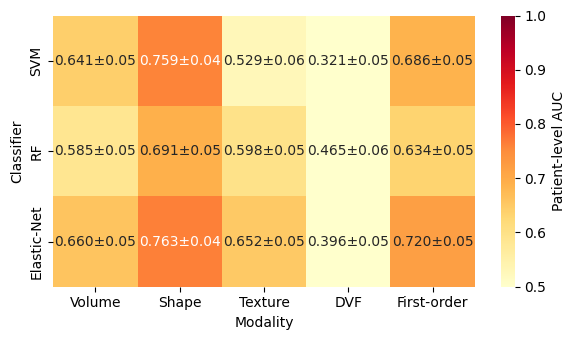

Salvo: artigo/figures/heatmap_smci_pmci_q4.pdf


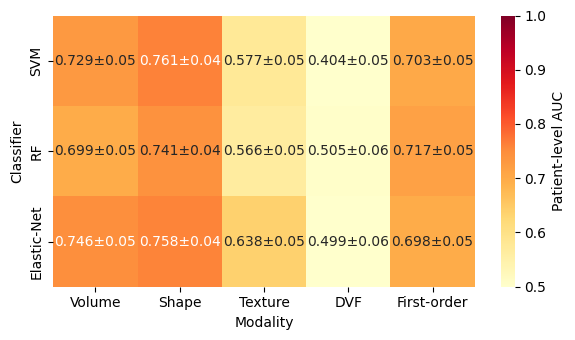

Salvo: artigo/figures/heatmap_cn_ad.pdf


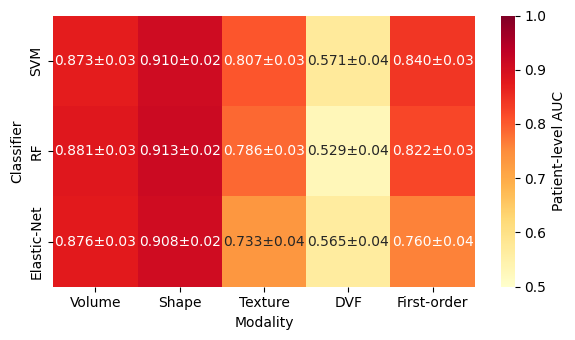

Salvo: artigo/figures/roc_smci_pmci_t1_shape.pdf


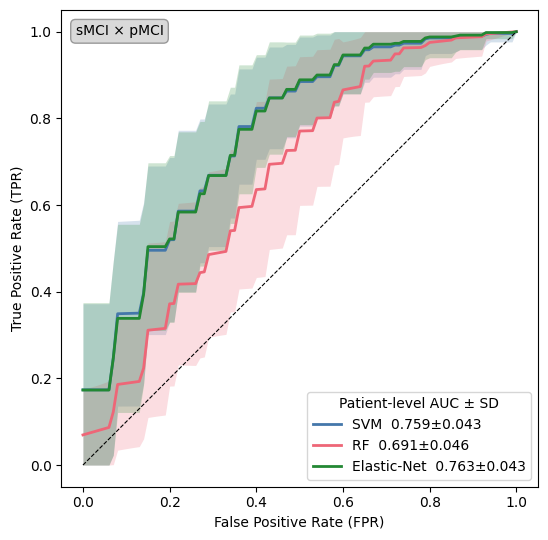

Salvo: artigo/figures/roc_smci_pmci_q4_shape.pdf


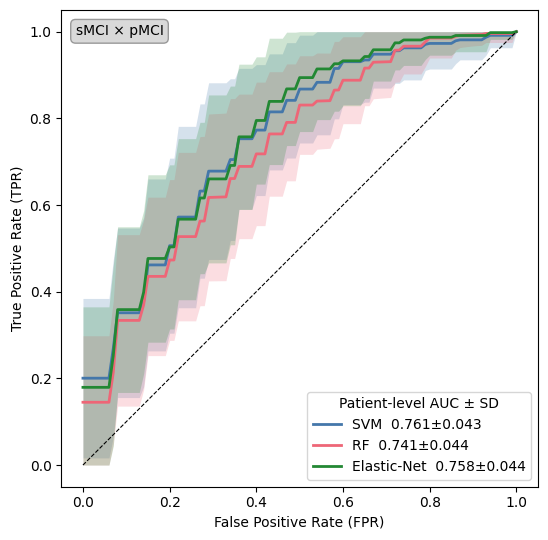

Salvo: artigo/figures/roc_cn_ad.pdf


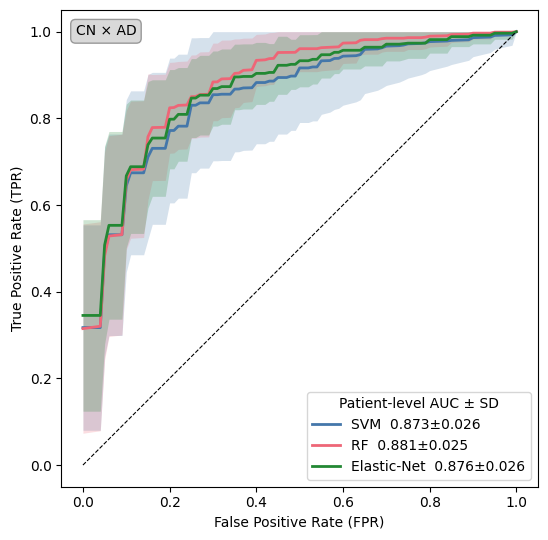

Estabilidade (t1_only) | sMCI × pMCI | svm | ≥70%


In [5]:
# Âncora A — figuras T1 + sanity cn_ad (Q4 vol)
_tag = f"{CFG.selection_mode}_" + ("combat" if CFG.with_combat else "nocombat")
print("Âncora A | t1_only | tasks:", sorted(ablation_t1["task"].astype(str).unique()))
print("mods t1:", sorted(ablation_t1["modality"].astype(str).unique()))
print("mods q4:", sorted(ablation_q4["modality"].astype(str).unique()))

plot_heatmap(
    ablation_t1, CFG.task_primary,
    title="", fname=f"heatmap_{CFG.task_primary}_t1",
)
plot_heatmap(
    ablation_q4, CFG.task_primary,
    title="", fname=f"heatmap_{CFG.task_primary}_q4",
)
try:
    plot_heatmap(
        ablation_q4, CFG.task_sanity,
        title="", fname=f"heatmap_{CFG.task_sanity}",
    )
except Exception as e:
    print(f"heatmap cn_ad skip: {e}")

plot_roc_models(
    ablation_t1, CFG.task_primary, CFG.modality_primary,
    title="", fname=f"roc_{CFG.task_primary}_t1_shape", score_agg="patient_mean",
)
plot_roc_models(
    ablation_q4, CFG.task_primary, CFG.modality_primary,
    title="", fname=f"roc_{CFG.task_primary}_q4_shape", score_agg="patient_mean",
)
try:
    plot_roc_models(
        ablation_q4, CFG.task_sanity, CFG.modality_sanity,
        title="", fname=f"roc_{CFG.task_sanity}", score_agg="patient_mean",
    )
except Exception as e:
    print(f"roc cn_ad skip: {e} — pasta vol_cn_ad")

stab_tbl = build_stability_table(ablation_t1, CFG.task_primary, CFG.model_primary)
print(
    f"Estabilidade (t1_only) | {TASK_LABELS[CFG.task_primary]} | {CFG.model_primary} "
    f"| ≥{STAB_MIN_PCT}%"
)


## 3. Encoding multi-cohort — claim longitudinal (Q4 vs T1)

**Hipótese:** Q4 (`t1_d21_d32`) vs `t1_only` nas 4 células. Não é lei: `36m_12m` pode inverter.

1. Tabela T1 / Q4 × modalidade × cohort
2. Barras AUC ± SD
3. Heatmap Δ(Q4 − T1)
4. Recorte **shape** (teto unimodal)

Exploratório (sem FDR entre cohorts). `REBUILD_COMPARE=False` = cache. Late em `ablation_results_late_fusion/`.


Carrega cache: csvs/cohort_comparison/cohort_results.csv (REBUILD_COMPARE=False)
Usando 201 linhas results (sem backup/_cn_ad; cohorts=['36m_6m', '36m_12m', '48m_6m', '48m_12m'])
Features: 5699 linhas
CSV: csvs/cohort_comparison/encoding_vs_t1_by_modality.csv
Δ(Q4−T1) patient AUC:


/mnt/study-data/pgirardi/tmp/ipykernel_1597723/2228790863.py:116: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_t1 = cmp.pivot_table(index="cohort", columns="modality", values="auc_t1", aggfunc="first")
/mnt/study-data/pgirardi/tmp/ipykernel_1597723/2228790863.py:117: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_q4 = cmp.pivot_table(index="cohort", columns="modality", values="auc_q4", aggfunc="first")
/mnt/study-data/pgirardi/tmp/ipykernel_1597723/2228790863.py:118: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain t

modality,vol,shape,texture,disp,firstorder
cohort,,,,,
36m_6m,0.005,-0.003,0.070,-0.051,0.016
36m_12m,-0.006,-0.027,0.016,-0.030,-0.025
48m_6m,0.007,-0.010,0.047,-0.017,-0.000
48m_12m,0.089,0.002,0.048,0.083,0.017


Salvo: artigo/figures/cohort_encoding_vs_t1_modalities.pdf


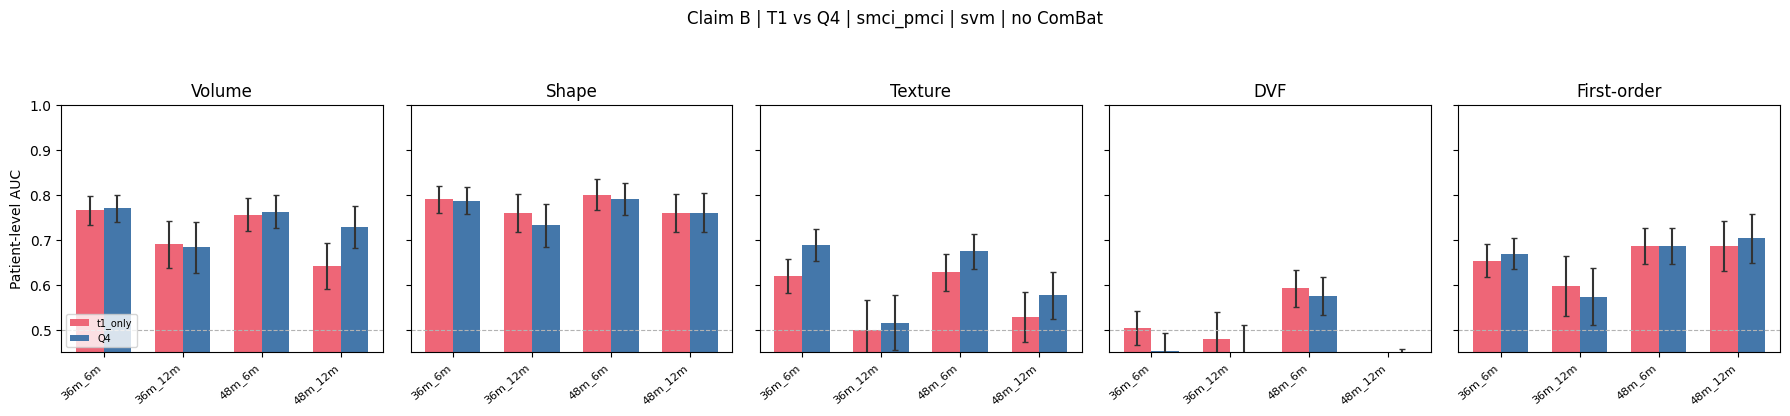

Salvo: artigo/figures/cohort_encoding_vs_t1_modalities_boxplot.pdf


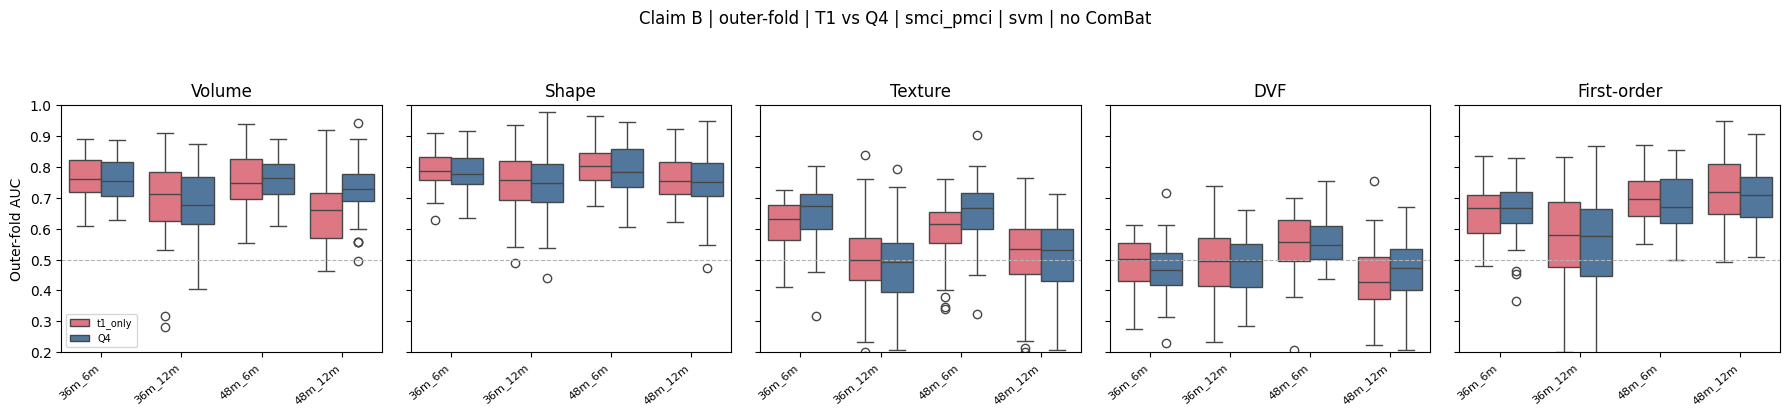


Claim B | recorte shape (gradiente):


,cohort,n_smci,n_pmci,auc_t1,sd_t1,auc_q4,sd_q4,delta_q4_t1,auc_pooled_t1,auc_pooled_q4,...,sens_pos_mean_q4,sens_pos_std_q4,spec_neg_mean_t1,spec_neg_std_t1,spec_neg_mean_q4,spec_neg_std_q4,f1_pos_mean_t1,f1_pos_std_t1,f1_pos_mean_q4,f1_pos_std_q4
1,36m_6m,125,106,0.7907,0.0299,0.7875,0.0301,-0.0032,0.7888,0.7744,...,0.7641,0.1095,0.6951,0.0922,0.6424,0.1240,0.7068,0.0732,0.6983,0.0607
6,36m_12m,121,33,0.7595,0.0427,0.7325,0.0474,-0.0270,0.7399,0.7006,...,0.6328,0.2749,0.6224,0.1861,0.6406,0.2266,0.4837,0.1074,0.4113,0.1544
11,48m_6m,73,120,0.8009,0.0347,0.7909,0.0357,-0.0100,0.7986,0.7819,...,0.7708,0.1269,0.6555,0.0997,0.6417,0.1277,0.7787,0.0689,0.7700,0.0761
16,48m_12m,72,48,0.7592,0.0427,0.7609,0.0430,0.0017,0.7492,0.7425,...,0.7037,0.1993,0.6264,0.0963,0.6477,0.1355,0.6480,0.0883,0.6188,0.1184


Salvo: artigo/figures/cohort_primary_encoding_vs_t1.pdf


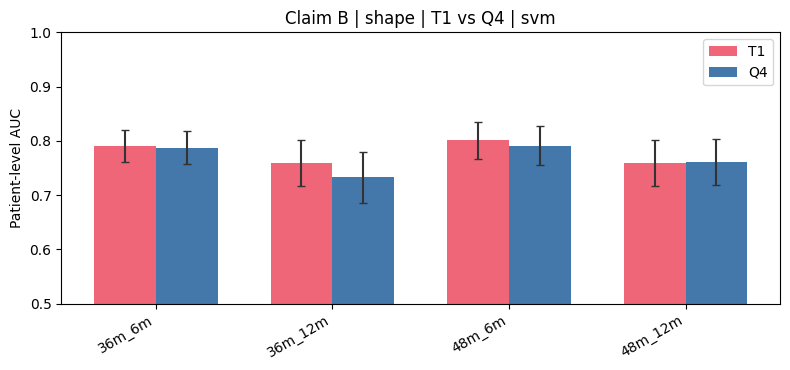

Salvo: artigo/figures/cohort_primary_encoding_boxplot.pdf


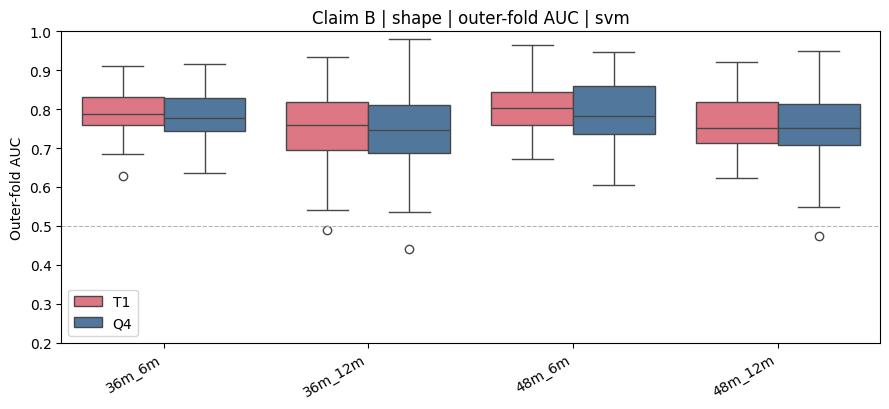

In [6]:
import importlib
import cohort_compare

importlib.reload(cohort_compare)
from cohort_compare import METRIC_PAIRS, save_cohort_comparison, read_cohort_results

BACKUP_RE = r"backup|_cn_ad"
# métricas do summary (fold-level) + pooled; patient AUC tratado à parte
_SUMMARY_METRIC_COLS = ["auc_pooled"] + [c for pair in METRIC_PAIRS for c in pair]
# só gaps 6m / 12m (9m fora do paper)
COHORT_ORDER = [c for c in (
    "36m_6m", "36m_12m", "48m_6m", "48m_12m",
) if c in COHORTS_COMPARE]


def _drop_backup_rows(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "source_file" not in df.columns:
        return df
    return df.loc[
        ~df["source_file"].astype(str).str.contains(BACKUP_RE, regex=True, na=False)
    ].copy()


REBUILD_COMPARE = False  # True = re-bootstrap completo (lento); cache pode ainda ter 9m

if not COHORTS_COMPARE:
    print("Nenhum cohort com ablation_results_t1_only/ — rode 5_ablation antes.")
else:
    p_res = COMPARE_DIR / "cohort_results.csv"
    p_feat = COMPARE_DIR / "cohort_features_long.csv"
    if REBUILD_COMPARE or not p_res.is_file():
        print("Cohorts:", COHORTS_COMPARE)
        p_res, p_feat, cohort_results, cohort_features = save_cohort_comparison(
            COHORTS_COMPARE,
            COMPARE_DIR,
            cohorts_root=COHORTS_DIR,
            n_boot=N_BOOT_AUC,
        )
    else:
        print(f"Carrega cache: {p_res} (REBUILD_COMPARE=False)")
        cohort_results = read_cohort_results(p_res)
        cohort_features = pd.read_csv(p_feat) if p_feat.is_file() else pd.DataFrame()

    cohort_results = _drop_backup_rows(cohort_results)
    if not cohort_features.empty and "source_file" in cohort_features.columns:
        cohort_features = _drop_backup_rows(cohort_features)
    # cache antigo ainda tem 9m — restringe ao que está em COHORTS_COMPARE
    cohort_results = cohort_results.loc[
        cohort_results["cohort"].astype(str).isin(COHORTS_COMPARE)
    ].copy()
    if not cohort_features.empty and "cohort" in cohort_features.columns:
        cohort_features = cohort_features.loc[
            cohort_features["cohort"].astype(str).isin(COHORTS_COMPARE)
        ].copy()
    if "with_combat" in cohort_results.columns:
        cohort_results["with_combat"] = cohort_results["with_combat"].map(
            lambda x: str(x).strip().lower() in ("1", "true", "yes")
        )
    print(f"Usando {len(cohort_results)} linhas results (sem backup/_cn_ad; cohorts={COHORTS_COMPARE})")
    print(f"Features: {len(cohort_features)} linhas")


    # ── t1 / Q4 × modality × cohort (svm, no ComBat, smci_pmci) ──
    PROTO_ENC = ("t1_only", "t1_d21_d32")
    base = cohort_results.query(
        "task == @CFG.task_primary and model_key == @CFG.model_primary "
        "and with_combat == False and protocol in @PROTO_ENC"
    ).copy()
    key = ["cohort", "protocol", "modality"]
    base = base.sort_values(key).drop_duplicates(subset=key, keep="last")

    meta_cols = ["cohort", "t_janela", "t_imagens", "n_smci", "n_pmci", "modality"]
    sum_cols = [c for c in _SUMMARY_METRIC_COLS if c in base.columns]

    def _enc_slice(proto: str, suffix: str, *, with_meta: bool) -> pd.DataFrame:
        cols = (meta_cols if with_meta else ["cohort", "modality"]) + [
            "auc_patient_mean", "auc_patient_std", *sum_cols,
        ]
        rename = {
            "auc_patient_mean": f"auc_{suffix}",
            "auc_patient_std": f"sd_{suffix}",
            **{c: f"{c}_{suffix}" for c in sum_cols},
        }
        return base.query("protocol == @proto")[cols].rename(columns=rename)

    t1 = _enc_slice("t1_only", "t1", with_meta=True)
    q4 = _enc_slice("t1_d21_d32", "q4", with_meta=False)

    cmp = t1.merge(q4, on=["cohort", "modality"], how="inner")
    cmp["delta_q4_t1"] = cmp["auc_q4"] - cmp["auc_t1"]
    cmp["modality"] = pd.Categorical(cmp["modality"], categories=MOD_ORDER, ordered=True)
    cmp["cohort"] = pd.Categorical(cmp["cohort"], categories=COHORT_ORDER, ordered=True)
    cmp = cmp.sort_values(["cohort", "modality"]).reset_index(drop=True)

    _auc_block = ["auc_t1", "sd_t1", "auc_q4", "sd_q4", "delta_q4_t1"]
    _extra_block = []
    for mean_c, std_c in [("auc_pooled", None), *METRIC_PAIRS]:
        for sfx in ("t1", "q4"):
            m = f"{mean_c}_{sfx}"
            if m in cmp.columns:
                _extra_block.append(m)
            if std_c is not None:
                s = f"{std_c}_{sfx}"
                if s in cmp.columns:
                    _extra_block.append(s)
    _show_cols = [
        c for c in [*meta_cols, *_auc_block, *_extra_block] if c in cmp.columns
    ]

    _dup_n = int(cmp.duplicated(["cohort", "modality"]).sum())
    if _dup_n:
        print(f"aviso: {_dup_n} linhas duplicadas (cohort, modality) — keep=last")
        print(cmp.loc[cmp.duplicated(["cohort", "modality"], keep=False), ["cohort", "modality"]])
    cmp = cmp.drop_duplicates(subset=["cohort", "modality"], keep="last")

    pivot_t1 = cmp.pivot_table(index="cohort", columns="modality", values="auc_t1", aggfunc="first")
    pivot_q4 = cmp.pivot_table(index="cohort", columns="modality", values="auc_q4", aggfunc="first")
    pivot_d = cmp.pivot_table(index="cohort", columns="modality", values="delta_q4_t1", aggfunc="first")

    COMPARE_DIR.mkdir(parents=True, exist_ok=True)
    enc_path = COMPARE_DIR / "encoding_vs_t1_by_modality.csv"
    cmp.to_csv(enc_path, index=False)
    print(f"CSV: {enc_path}")
    print("Δ(Q4−T1) patient AUC:")
    display(pivot_d.round(3))

    mods_plot = [m for m in MOD_ORDER if m in cmp["modality"].astype(str).unique()]
    n_mod = len(mods_plot)
    if n_mod and len(cmp):
        fig, axes = plt.subplots(
            1, n_mod, figsize=(3.6 * n_mod, 4.2), sharey=True, squeeze=False,
        )
        x = np.arange(len(COHORT_ORDER))
        w = 0.35
        for ax, mod in zip(axes[0], mods_plot):
            sub = cmp.loc[cmp["modality"] == mod].set_index("cohort").reindex(COHORT_ORDER)
            ax.bar(x - w / 2, sub["auc_t1"], w, yerr=sub["sd_t1"],
                   capsize=2, label="t1_only", color="#EE6677", ecolor="#333333")
            ax.bar(x + w / 2, sub["auc_q4"], w, yerr=sub["sd_q4"],
                   capsize=2, label="Q4", color="#4477AA", ecolor="#333333")
            ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
            ax.set_xticks(x)
            ax.set_xticklabels(COHORT_ORDER, rotation=40, ha="right", fontsize=8)
            ax.set_title(MOD_LABELS.get(mod, mod))
            ax.set_ylim(0.45, 1.0)
            if ax is axes[0, 0]:
                ax.set_ylabel("Patient-level AUC")
                ax.legend(fontsize=7, loc="lower left")
        fig.suptitle(
            f"Claim B | T1 vs Q4 | {CFG.task_primary} | {CFG.model_primary} | no ComBat",
        )
        fig.tight_layout(rect=[0, 0, 1, 0.92])
        save_fig(fig, "cohort_encoding_vs_t1_modalities")
        plt.show()

        _proto_dirs = {
            "t1_only": "ablation_results_t1_only",
            "Q4": "ablation_results_d21d32",
        }
        _enc_colors = {"t1_only": "#EE6677", "Q4": "#4477AA"}
        rows_bp = []
        for mod in mods_plot:
            for cohort in COHORT_ORDER:
                for label, dirname in _proto_dirs.items():
                    path = COHORTS_DIR / cohort / dirname / mod / "ablation_results_all.csv"
                    if not path.is_file():
                        continue
                    try:
                        sub = filter_ablation_config(
                            pd.read_csv(path),
                            task=CFG.task_primary,
                            modality=mod,
                            model_key=CFG.model_primary,
                            with_combat=CFG.with_combat,
                            selection_mode=CFG.selection_mode,
                        )
                    except ValueError:
                        continue
                    for v in sub["auc"].astype(float):
                        rows_bp.append({
                            "cohort": cohort,
                            "modality": mod,
                            "encoding": label,
                            "auc": float(v),
                        })
        bp = pd.DataFrame(rows_bp)
        if bp.empty:
            print("boxplot multi-mod: sem dados")
        else:
            n_mod = len(mods_plot)
            fig, axes = plt.subplots(
                1, n_mod, figsize=(3.6 * n_mod, 4.2), sharey=True, squeeze=False,
            )
            for ax, mod in zip(axes[0], mods_plot):
                sub = bp.loc[bp["modality"] == mod]
                sns.boxplot(
                    data=sub, x="cohort", y="auc", hue="encoding",
                    order=COHORT_ORDER, hue_order=list(_proto_dirs),
                    palette=_enc_colors, ax=ax,
                )
                ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
                ax.set_title(MOD_LABELS.get(mod, mod))
                ax.set_xlabel("")
                ax.set_ylim(0.2, 1.0)
                plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
                if ax is axes[0, 0]:
                    ax.set_ylabel("Outer-fold AUC")
                    ax.legend(fontsize=7, loc="lower left")
                else:
                    leg = ax.get_legend()
                    if leg is not None:
                        leg.remove()
            fig.suptitle(
                f"Claim B | outer-fold | T1 vs Q4 | {CFG.task_primary} | "
                f"{CFG.model_primary} | no ComBat",
            )
            fig.tight_layout(rect=[0, 0, 1, 0.92])
            save_fig(fig, "cohort_encoding_vs_t1_modalities_boxplot")
            plt.show()

    primary = cmp.query("modality == @CFG.modality_primary").copy()
    print(f"\nClaim B | recorte {CFG.modality_primary} (gradiente):")
    _prim_cols = [
        c for c in [
            "cohort", "n_smci", "n_pmci",
            "auc_t1", "sd_t1", "auc_q4", "sd_q4", "delta_q4_t1",
            *_extra_block,
        ] if c in primary.columns
    ]
    if len(primary):
        display(primary[_prim_cols].round(4))
        fig, ax = plt.subplots(figsize=(8, 3.8))
        x = np.arange(len(primary))
        w = 0.35
        ax.bar(x - w / 2, primary["auc_t1"], w, yerr=primary["sd_t1"],
               capsize=3, label="T1", color="#EE6677", ecolor="#333333")
        ax.bar(x + w / 2, primary["auc_q4"], w, yerr=primary["sd_q4"],
               capsize=3, label="Q4", color="#4477AA", ecolor="#333333")
        ax.set_xticks(x)
        ax.set_xticklabels(primary["cohort"].astype(str), rotation=30, ha="right")
        ax.set_ylabel("Patient-level AUC")
        ax.set_ylim(0.5, 1.0)
        ax.legend()
        ax.set_title(
            f"Claim B | {CFG.modality_primary} | T1 vs Q4 | {CFG.model_primary}"
        )
        plt.tight_layout()
        save_fig(fig, "cohort_primary_encoding_vs_t1")
        plt.show()

        _proto_dirs = {
            "T1": "ablation_results_t1_only",
            "Q4": "ablation_results_d21d32",
        }
        _enc_colors = {"T1": "#EE6677", "Q4": "#4477AA"}
        rows_bp = []
        for cohort in primary["cohort"].astype(str):
            for label, dirname in _proto_dirs.items():
                path = (
                    COHORTS_DIR / cohort / dirname
                    / CFG.modality_primary / "ablation_results_all.csv"
                )
                if not path.is_file():
                    continue
                try:
                    sub = filter_ablation_config(
                        pd.read_csv(path),
                        task=CFG.task_primary,
                        modality=CFG.modality_primary,
                        model_key=CFG.model_primary,
                        with_combat=CFG.with_combat,
                        selection_mode=CFG.selection_mode,
                    )
                except ValueError:
                    continue
                for v in sub["auc"].astype(float):
                    rows_bp.append({"cohort": cohort, "encoding": label, "auc": float(v)})
        bp = pd.DataFrame(rows_bp)
        fig, ax = plt.subplots(figsize=(9, 4.2))
        if bp.empty:
            ax.set_title("sem AUCs outer-fold para boxplot")
        else:
            order = [c for c in COHORT_ORDER if c in set(bp["cohort"])]
            sns.boxplot(
                data=bp, x="cohort", y="auc", hue="encoding",
                order=order, hue_order=list(_proto_dirs),
                palette=_enc_colors, ax=ax,
            )
            ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
            ax.set_ylabel("Outer-fold AUC")
            ax.set_xlabel("")
            ax.set_ylim(0.2, 1.0)
            ax.legend(title="", loc="lower left")
            ax.set_title(
                f"Claim B | {CFG.modality_primary} | outer-fold AUC | {CFG.model_primary}"
            )
            plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
        plt.tight_layout()
        save_fig(fig, "cohort_primary_encoding_boxplot")
        plt.show()


48m_12m | teto unimodal=0.759 | teto uniao T1=0.740
  0.759±0.043  ceiling  forma t0
  0.740±0.046  ceiling  late uniao t0
  0.765±0.044  pass     late tudo Q4
  0.767±0.044  claim    late ancora
Salvo: artigo/figures/fusion_vs_ceilings_48m12.pdf


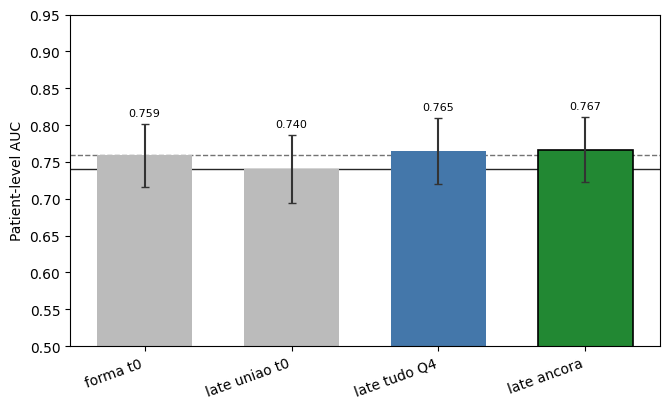

In [7]:
# Late fusion vs teto unimodal (shape T1) e união-baseline — 48m_12m
CLAIM_COHORT = "48m_12m"
res = pd.read_csv(COMPARE_DIR / "cohort_results.csv")
res["with_combat"] = res["with_combat"].map(
    lambda x: str(x).strip().lower() in ("1", "true", "yes")
)
res = res.loc[
    (res["cohort"].astype(str) == CLAIM_COHORT)
    & (res["task"].astype(str) == CFG.task_primary)
    & (res["model_key"].astype(str) == CFG.model_primary)
    & (res["with_combat"] == False)
].copy()


def _auc(protocol: str, modality: str | None = None) -> tuple[float, float]:
    sub = res.loc[res["protocol"].astype(str) == protocol]
    if modality is not None:
        sub = sub.loc[sub["modality"].astype(str) == modality]
    if sub.empty:
        raise KeyError(f"missing {CLAIM_COHORT} {protocol}/{modality}")
    r = sub.iloc[0]
    return float(r["auc_patient_mean"]), float(r["auc_patient_std"])


SPECS = [
    ("forma t0", "t1_only", "shape", "ceiling"),
    ("late uniao t0", LATE_ALL_T1, LATE_ALL_T1, "ceiling"),
    ("late tudo Q4", LATE_ALL_Q4, LATE_ALL_Q4, "pass"),
    ("late ancora", LATE_ANCORA, LATE_ANCORA, "claim"),
]
COLORS = {
    "ceiling": "#BBBBBB",
    "fail": "#EE6677",
    "pass": "#4477AA",
    "claim": "#228833",
}

rows = [(lab, *_auc(proto, mod), role) for lab, proto, mod, role in SPECS]
auc_uni = rows[0][1]
auc_union = rows[1][1]
print(f"{CLAIM_COHORT} | teto unimodal={auc_uni:.3f} | teto uniao T1={auc_union:.3f}")
for lab, auc, sd, role in rows:
    print(f"  {auc:.3f}±{sd:.3f}  {role:7s}  {lab}")

fig, ax = plt.subplots(figsize=(6.8, 4.2))
x = np.arange(len(rows))
ax.bar(
    x, [r[1] for r in rows], 0.65,
    yerr=[r[2] for r in rows], capsize=3,
    color=[COLORS[r[3]] for r in rows], ecolor="#333333",
    edgecolor=["black" if r[3] == "claim" else "none" for r in rows],
    linewidth=1.2,
)
for i, (_, auc, sd, _) in enumerate(rows):
    ax.text(i, auc + sd + 0.008, f"{auc:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in rows], rotation=20, ha="right")
ax.set_ylabel("Patient-level AUC")
ax.set_ylim(0.50, 0.95)
ax.axhline(auc_uni, color="0.45", ls="--", lw=1.0, zorder=0)
ax.axhline(auc_union, color="0.15", ls="-", lw=1.0, zorder=0)
plt.tight_layout()
save_fig(fig, "fusion_vs_ceilings_48m12")
